In [2]:
#for fetching data from single pages
import pandas as pd
cc = pd.read_csv('CC_data.csv')
cc.head()

,Male,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43,560,+
2,a,24.5,0.500,u,g,q,h,1.50,t,f,0,f,g,280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120,0,+


In [3]:
cc.columns

Index(['Male', 'Age', 'Debt', 'Married', 'BankCustomer', 'EducationLevel',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved'],
      dtype='object')

In [4]:
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Male            690 non-null    object 
 1   Age             690 non-null    object 
 2   Debt            690 non-null    float64
 3   Married         690 non-null    object 
 4   BankCustomer    690 non-null    object 
 5   EducationLevel  690 non-null    object 
 6   Ethnicity       690 non-null    object 
 7   YearsEmployed   690 non-null    float64
 8   PriorDefault    690 non-null    object 
 9   Employed        690 non-null    object 
 10  CreditScore     690 non-null    int64  
 11  DriversLicense  690 non-null    object 
 12  Citizen         690 non-null    object 
 13  ZipCode         690 non-null    object 
 14  Income          690 non-null    int64  
 15  Approved        690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


In [5]:
cc.describe()

,Debt,YearsEmployed,CreditScore,Income
count,690.000000,690.000000,690.00000,690.000000
mean,4.758725,2.223406,2.40000,1017.385507
std,4.978163,3.346513,4.86294,5210.102598
min,0.000000,0.000000,0.00000,0.000000
25%,1.000000,0.165000,0.00000,0.000000
50%,2.750000,1.000000,0.00000,5.000000
75%,7.207500,2.625000,3.00000,395.500000
max,28.000000,28.500000,67.00000,100000.000000


In [7]:
cc.describe().T

,count,mean,std,min,25%,50%,75%,max
Debt,690.0,4.758725,4.978163,0.0,1.000,2.75,7.2075,28.0
YearsEmployed,690.0,2.223406,3.346513,0.0,0.165,1.00,2.6250,28.5
CreditScore,690.0,2.400000,4.862940,0.0,0.000,0.00,3.0000,67.0
Income,690.0,1017.385507,5210.102598,0.0,0.000,5.00,395.5000,100000.0


In [9]:
cc.isnull().sum()

Male              0
Age               0
Debt              0
Married           0
BankCustomer      0
EducationLevel    0
Ethnicity         0
YearsEmployed     0
PriorDefault      0
Employed          0
CreditScore       0
DriversLicense    0
Citizen           0
ZipCode           0
Income            0
Approved          0
dtype: int64

In [11]:
# Import label encoder 
from sklearn import preprocessing 
  
# label_encoder object knows  
# how to understand word labels. 
label_encoder = preprocessing.LabelEncoder() 
  
# Encode labels in column 'species'. 
cc['Approved']= label_encoder.fit_transform(cc['Approved']) 
  
cc['Approved'].unique() 

array([0, 1])

In [15]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Instantiate LabelEncoder
le = LabelEncoder()

# Iterate over all the values of each column and extract their dtypes
for col in cc.columns.values:
    # Compare if the dtype is object
    if cc[col].dtype =='object':
    # Use LabelEncoder to do the numeric transformation
        cc[col]=le.fit_transform(cc[col])

Approved
1    383
0    307
Name: count, dtype: int64


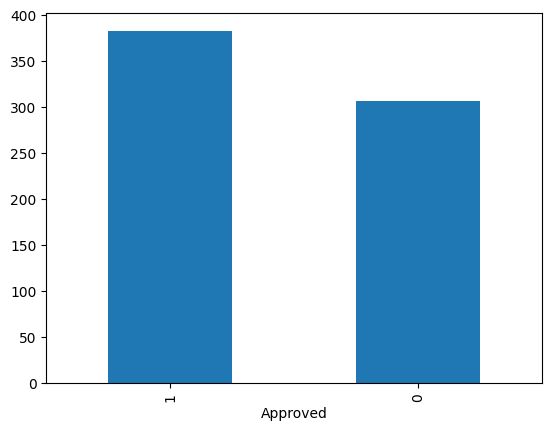

In [16]:
#to check how well our outcome column is balanced
color_wheel = {1: "#0392cf", 2: "#7bc043"}
colors = cc["Approved"].map(lambda x: color_wheel.get(x + 1))
print(cc.Approved.value_counts())
p=cc.Approved.value_counts().plot(kind="bar")


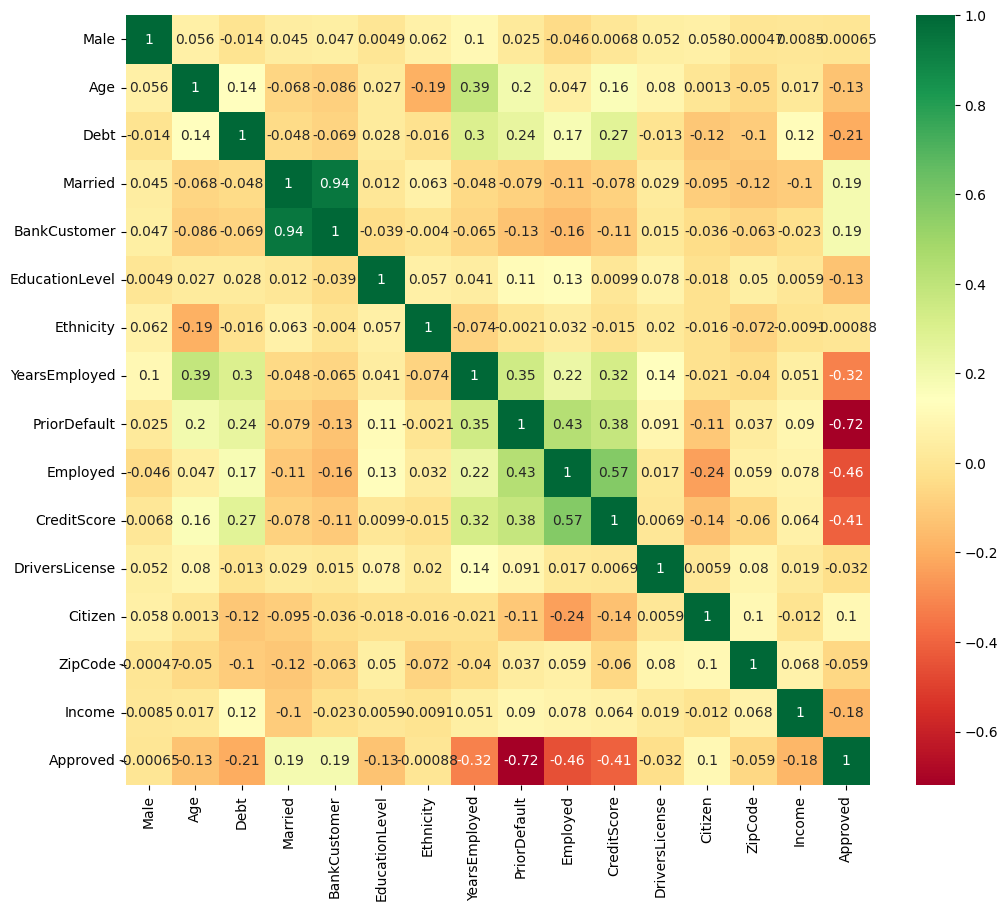

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
# Correlation between all the features before cleaning
plt.figure(figsize=(12,10))
# seaborn has an easy method to showcase heatmap
p = sns.heatmap(cc.corr(), annot=True,cmap ='RdYlGn')

In [18]:
#splitting the data
X = cc.drop('Approved', axis=1)
y = cc['Approved']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33,
                                                    random_state=7)

In [20]:
#Building the model using RandomForest
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=200)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [21]:
#Now after building the model let’s check the accuracy of the model on the training dataset.

rfc_train = rfc.predict(X_train)
from sklearn import metrics

print("Accuracy_Score =", format(metrics.accuracy_score(y_train, rfc_train)))

Accuracy_Score = 1.0


In [23]:
#Getting the accuracy score for Random Forest

from sklearn import metrics

predictions = rfc.predict(X_test)
print("Accuracy_Score =", format(metrics.accuracy_score(y_test, predictions)))

Accuracy_Score = 0.868421052631579


In [24]:
#Classification report and confusion matrix of the RFC model
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test,predictions))

[[ 82  14]
 [ 16 116]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85        96
           1       0.89      0.88      0.89       132

    accuracy                           0.87       228
   macro avg       0.86      0.87      0.87       228
weighted avg       0.87      0.87      0.87       228



In [25]:
#Getting feature importances

rfc.feature_importances_

array([0.01467406, 0.07141707, 0.0883228 , 0.01298659, 0.01310802,
       0.06817799, 0.02679771, 0.10367229, 0.27649036, 0.06113512,
       0.08909226, 0.01219373, 0.0089782 , 0.0748733 , 0.0780805 ])

<AxesSubplot: >

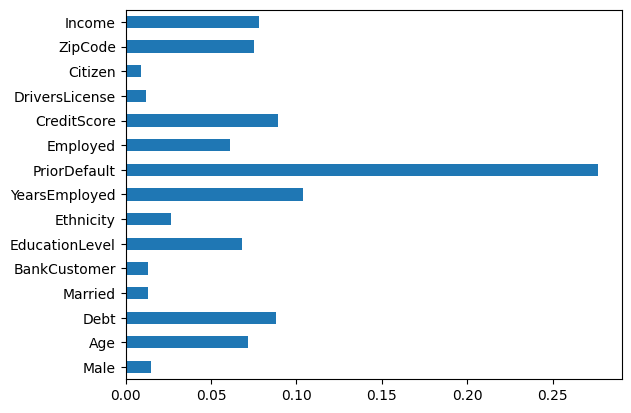

In [26]:
#Plotting feature importances

(pd.Series(rfc.feature_importances_, index=X.columns).plot(kind='barh'))

In [27]:
#saving the model
import pickle

# Firstly we will be using the dump() function to save the model using pickle
saved_model = pickle.dumps(rfc)

# Then we will be loading that saved model
rfc_from_pickle = pickle.loads(saved_model)

# lastly, after loading that model we will use this to make predictions
rfc_from_pickle.predict(X_test)

array([1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0])

In [28]:
cc.head()

,Male,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,2,156,0.000,2,1,13,8,1.25,1,1,1,0,0,42,0,0
1,1,328,4.460,2,1,11,4,3.04,1,1,6,0,0,118,560,0
2,1,89,0.500,2,1,11,4,1.50,1,0,0,0,0,74,824,0
3,2,125,1.540,2,1,13,8,3.75,1,1,5,1,0,1,3,0
4,2,43,5.625,2,1,13,8,1.71,1,0,0,0,2,8,0,0


In [36]:
df1=pd.DataFrame(X)
df1

,Male,Age,Debt,Married,BankCustomer,EducationLevel,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income
0,2,156,0.000,2,1,13,8,1.25,1,1,1,0,0,42,0
1,1,328,4.460,2,1,11,4,3.04,1,1,6,0,0,118,560
2,1,89,0.500,2,1,11,4,1.50,1,0,0,0,0,74,824
3,2,125,1.540,2,1,13,8,3.75,1,1,5,1,0,1,3
4,2,43,5.625,2,1,13,8,1.71,1,0,0,0,2,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,2,52,10.085,3,3,5,4,1.25,0,0,0,0,0,67,0
686,1,71,0.750,2,1,2,8,2.00,0,1,2,1,0,40,394
687,1,97,13.500,3,3,6,3,2.00,0,1,1,1,0,40,1
688,2,20,0.205,2,1,1,8,0.04,0,0,0,0,0,74,750


In [37]:
#predicting for row 2
# 0 is approved, 1 is not approved
rfc.predict(df1.loc[[2]])

array([0])

In [39]:
df2=pd.DataFrame(y)
df2

,Approved
0,0
1,0
2,0
3,0
4,0
...,...
685,1
686,1
687,1
688,1


In [41]:
df2.loc[[2]]

,Approved
2,0


Hence our model is performing well on test data

In [ ]:
import tkinter as tk
import pyttsx3
import webbrowser



# create the main window
root = tk.Tk()
root.title('Credit Card Prediction App')
# create the first canvas
canvas1 = tk.Canvas(root, width=800, height=500)
canvas1.pack()

# create the image on the canvas
canvas1.create_image(0, 0, anchor="nw")
canvas1.create_text(400, 50, text=' Credit card prediction App ', font=('Times', 35))

# create the first button
def switch_to_canvas2():
    canvas1.pack_forget()
    canvas2.pack()


First_page = tk.Button(root, text='Predict Status', bg='orange', font='Times', fg='white', width=20, command=switch_to_canvas2)
canvas1.create_window(400, 470, window=First_page)

# create an "About Us" button
def about_us():
    friend = pyttsx3.init()
    friend.say("I am Aryan and I with the help of Avishek Sir created this app to help people predict their credit card status. ")
    friend.runAndWait()

About_us_button = tk.Button(root, text='About Us', bg='gray', font='Times', fg='white', width=10, command=about_us)
canvas1.create_window(730, 470, window=About_us_button)


# create the second canvas
canvas2 = tk.Canvas(root, width=400, height=650)
canvas2.configure(bg='wheat')


Details_label = tk.Label(canvas2, text=' Please enter your details ', bg='wheat', font='Times', fg='peru')
canvas2.create_window(200, 50, window=Details_label)

label7 = tk.Label(root, text=' Male : ')
canvas2.create_window(100, 400, window=label7)
entry7 = tk.Entry (root)

#create 7th entry box
canvas2.create_window(270, 400, window=entry7)
label7.configure(bg='wheat', font= 'Times', fg='peru')#

# Glucose Level label and input box
label1 = tk.Label(canvas2, text=' Age : ', bg='wheat', font='Times', fg='peru')
canvas2.create_window(100, 100, window=label1)
entry1 = tk.Entry(canvas2)
canvas2.create_window(270, 100, window=entry1)

# Blood Pressure label and input box
label2 = tk.Label(canvas2, text=' Married : ', bg='wheat', font='Times', fg='peru')
canvas2.create_window(100, 150, window=label2)
entry2 = tk.Entry(canvas2)
canvas2.create_window(270, 150, window=entry2)

# Skin Thickness label and input box
label3 = tk.Label(root, text=' BankCustomer : ')
canvas2.create_window(100, 200, window=label3)
entry3 = tk.Entry (root)
#create 3rd entry box
canvas2.create_window(270, 200, window=entry3)
label3.configure(bg='wheat', font= 'Times', fg='peru')

# Insulin label and input box
label4 = tk.Label(root, text=' EducationLevel : ')
canvas2.create_window(100, 250, window=label4)
entry4 = tk.Entry (root)
#create 4th entry box
canvas2.create_window(270, 250, window=entry4)
label4.configure(bg='wheat', font= 'Times', fg='peru')

# BMI label and input box
label5 = tk.Label(root, text=' Ethnicity : ')
canvas2.create_window(100, 300, window=label5)
entry5 = tk.Entry (root)
#create 5th entry box
canvas2.create_window(270, 300, window=entry5)
label5.configure(bg='wheat', font= 'Times', fg='peru')


# Age label and input box
label6 = tk.Label(root, text=' YearsEmployed : ')
canvas2.create_window(100, 350, window=label6)
entry6 = tk.Entry (root)
#create 6th entry box
canvas2.create_window(270, 350, window=entry6)
label6.configure(bg='wheat', font= 'Times', fg='peru')






# show the first canvas
root.mainloop()